In [1]:
import os
import pandas as pd, numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score, matthews_corrcoef
import shap

print(os.listdir("."))

['products.csv', 'orders.csv', 'market-prediction.ipynb', 'order_products__train.csv', 'order_products__prior.csv', 'aisles.csv', 'departments.csv', '.ipynb_checkpoints']


In [2]:
def run_cv(feat_list, label):
    X2 = d2[feat_list]
    aucs, aps, base = [], [], []
    for tr, te in GroupKFold(n_splits=5).split(X2, y2, g2):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                               min_child_samples=50, subsample=0.8, subsample_freq=1,
                               colsample_bytree=0.8, scale_pos_weight=3.5, random_state=42, verbose=-1)
        m.fit(X2.iloc[tr], y2.iloc[tr])
        p = m.predict_proba(X2.iloc[te])[:, 1]
        aucs.append(roc_auc_score(y2.iloc[te], p))
        aps.append(average_precision_score(y2.iloc[te], p))
        base.append(roc_auc_score(y2.iloc[te], X2.iloc[te]["buy_rate"]))
    print(f"[{label}] AUC average {np.mean(aucs):.3f} | AP average {np.mean(aps):.3f} | baseline AUC {np.mean(base):.3f}")
    return aucs, aps

def run_cv_full(feat_list, label, threshold=0.5):
    X2 = d2[feat_list]
    aucs, aps, f1s, precs, recs, mccs = [], [], [], [], [], []
    for tr, te in GroupKFold(n_splits=5).split(X2, y2, g2):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                               min_child_samples=50, subsample=0.8, subsample_freq=1,
                               colsample_bytree=0.8, scale_pos_weight=3.5, random_state=42, verbose=-1)
        m.fit(X2.iloc[tr], y2.iloc[tr])
        p = m.predict_proba(X2.iloc[te])[:, 1]
        pred = (p >= threshold).astype(int)
        aucs.append(roc_auc_score(y2.iloc[te], p))
        aps.append(average_precision_score(y2.iloc[te], p))
        f1s.append(f1_score(y2.iloc[te], pred))
        precs.append(precision_score(y2.iloc[te], pred))
        recs.append(recall_score(y2.iloc[te], pred))
        mccs.append(matthews_corrcoef(y2.iloc[te], pred))
    print(f"[{label}] AUC {np.mean(aucs):.3f} | AP {np.mean(aps):.3f} | "
          f"F1 {np.mean(f1s):.3f} | Precision {np.mean(precs):.3f} | "
          f"Recall {np.mean(recs):.3f} | MCC {np.mean(mccs):.3f}")

In [3]:
N = None
orders = pd.read_csv("orders.csv")
train_users = pd.Series(orders[orders.eval_set == "train"].user_id.unique())
print("Total user count:", len(train_users))

sample_users = train_users if N is None else train_users.sample(N, random_state=42)
orders_s = orders[orders.user_id.isin(sample_users)]
print(orders_s.eval_set.value_counts())

Total user count: 131209
eval_set
prior    2047377
train     131209
Name: count, dtype: int64


In [4]:
prior_ids = orders_s[orders_s.eval_set == "prior"].order_id.values
dt = {"order_id": "int32", "product_id": "int32",
      "add_to_cart_order": "int16", "reordered": "int8"}

chunks = []
for chunk in pd.read_csv("order_products__prior.csv", chunksize=2_000_000, dtype=dt):
    chunks.append(chunk[chunk.order_id.isin(prior_ids)])
prior_s = pd.concat(chunks)
print(prior_s.shape)

(20641991, 4)


In [5]:
train_ids = set(orders_s[orders_s.eval_set == "train"].order_id)

train = pd.read_csv("order_products__train.csv")
train_s = train[train.order_id.isin(train_ids)]

print(train_s.shape)
train_s.head()

(1384617, 4)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [6]:
up = prior_s.merge(orders_s[["order_id", "user_id", "order_number"]], on="order_id")
print(up.shape)
up.head()

(20641991, 6)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number
0,2,33120,1,1,202279,3
1,2,28985,2,1,202279,3
2,2,9327,3,0,202279,3
3,2,45918,4,1,202279,3
4,2,30035,5,0,202279,3


In [7]:
user_n = up.groupby("user_id").order_number.max().rename("user_orders")

feat = up.groupby(["user_id", "product_id"]).agg(
    times_bought=("order_id", "count"),
    last_order=("order_number", "max"),
    avg_cart_pos=("add_to_cart_order", "mean")
).reset_index()

feat = feat.merge(user_n, on="user_id")
feat["buy_rate"] = feat.times_bought / feat.user_orders
feat["orders_since_last"] = feat.user_orders - feat.last_order

prod = up.groupby("product_id").agg(
    prod_count=("order_id", "count"),
    prod_reorder=("reordered", "mean")
).reset_index()
feat = feat.merge(prod, on="product_id")

print(feat.shape)
feat.head()

(8474661, 10)


,user_id,product_id,times_bought,last_order,avg_cart_pos,user_orders,buy_rate,orders_since_last,prod_count,prod_reorder
0,1,196,10,10,1.400000,10,1.0,0,22920,0.778403
1,1,10258,9,10,3.333333,10,0.9,0,1303,0.716040
2,1,10326,1,5,5.000000,10,0.1,5,3525,0.646525
3,1,12427,10,10,3.300000,10,1.0,0,4008,0.741517
4,1,13032,3,10,6.333333,10,0.3,0,2455,0.655804


In [8]:
train_pairs = train_s.merge(orders_s[["order_id", "user_id"]], on="order_id")[["user_id", "product_id"]]
train_pairs["label"] = 1

data = feat.merge(train_pairs, on=["user_id", "product_id"], how="left")
data["label"] = data.label.fillna(0).astype(int)

print(data.shape)
print(data.label.mean())
data.head()

(8474661, 11)
0.09780025419305857


,user_id,product_id,times_bought,last_order,avg_cart_pos,user_orders,buy_rate,orders_since_last,prod_count,prod_reorder,label
0,1,196,10,10,1.400000,10,1.0,0,22920,0.778403,1
1,1,10258,9,10,3.333333,10,0.9,0,1303,0.716040,1
2,1,10326,1,5,5.000000,10,0.1,5,3525,0.646525,0
3,1,12427,10,10,3.300000,10,1.0,0,4008,0.741517,0
4,1,13032,3,10,6.333333,10,0.3,0,2455,0.655804,1


In [9]:
u = up.groupby("user_id").agg(n_items=("order_id", "count"),
                              user_reorder_ratio=("reordered", "mean")).reset_index()
u = u.merge(user_n.reset_index(), on="user_id")
u["user_basket"] = u.n_items / u.user_orders
u = u[["user_id", "user_reorder_ratio", "user_basket"]]

gap = (orders_s[orders_s.eval_set == "prior"].groupby("user_id")
       .days_since_prior_order.mean().rename("user_avg_days").reset_index())

fo = up.groupby(["user_id", "product_id"]).order_number.min().rename("first_order").reset_index()
up2 = up.merge(user_n.reset_index(), on="user_id")
r3 = (up2[up2.order_number > up2.user_orders - 3]
      .groupby(["user_id", "product_id"]).size().rename("cnt_last3").reset_index())

tgt = orders_s[orders_s.eval_set == "train"][["user_id", "days_since_prior_order",
                                              "order_dow", "order_hour_of_day"]]
tgt.columns = ["user_id", "target_days", "target_dow", "target_hour"]

d2 = (data.merge(u, on="user_id", how="left")
          .merge(gap, on="user_id", how="left")
          .merge(fo, on=["user_id", "product_id"], how="left")
          .merge(r3, on=["user_id", "product_id"], how="left")
          .merge(tgt, on="user_id", how="left"))

d2["cnt_last3"] = d2.cnt_last3.fillna(0)
span = d2.last_order - d2.first_order
d2["avg_gap"] = np.where(d2.times_bought > 1, span / (d2.times_bought - 1), np.nan)
d2["due_ratio"] = (d2.orders_since_last / d2.avg_gap).replace([np.inf, -np.inf], np.nan)

print(d2.shape)

features = ["times_bought", "last_order", "avg_cart_pos", "user_orders",
            "buy_rate", "orders_since_last", "prod_count", "prod_reorder"]

(8474661, 21)


In [10]:
feats_base = features  # 8 features (times_bought, last_order, avg_cart_pos, user_orders, buy_rate, orders_since_last, prod_count, prod_reorder)
feats_full = features + ["user_reorder_ratio", "user_basket", "user_avg_days", "cnt_last3",
                         "avg_gap", "due_ratio", "target_days", "target_dow", "target_hour"]

y2, g2 = d2["label"], d2["user_id"]

aucs_base, aps_base = run_cv(feats_base, "8 features")
aucs_full, aps_full = run_cv(feats_full, "full features")

[8 features] AUC average 0.827 | AP average 0.401 | baseline AUC 0.773
[full features] AUC average 0.834 | AP average 0.427 | baseline AUC 0.773


In [11]:
run_cv_full(feats_full, "full features")

[full features] AUC 0.834 | AP 0.427 | F1 0.444 | Precision 0.402 | Recall 0.496 | MCC 0.379


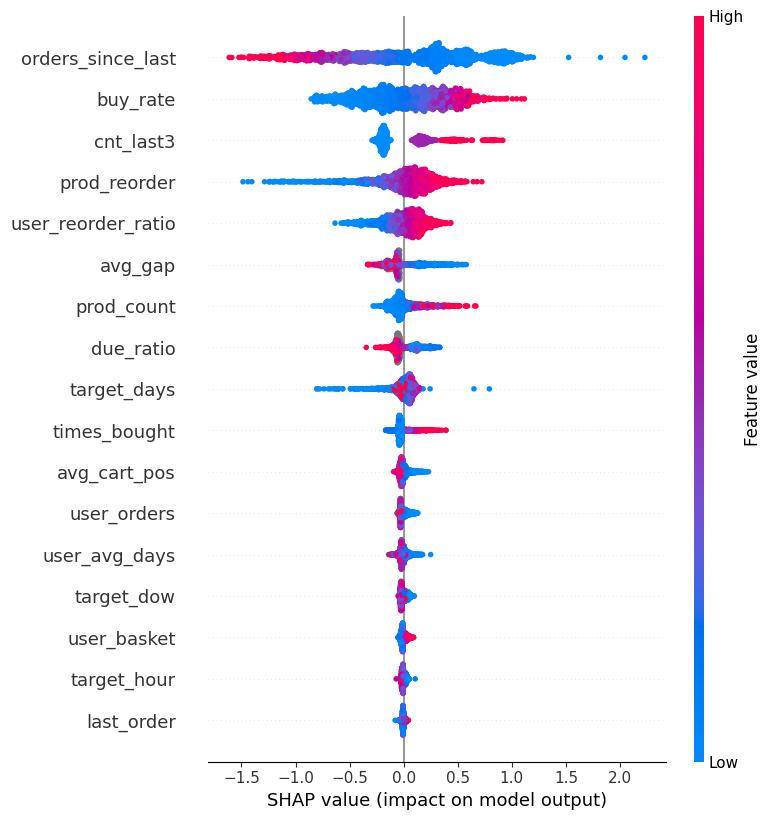

In [13]:
# SHAP
X2 = d2[feats_full]
final_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                                 min_child_samples=50, subsample=0.8, subsample_freq=1,
                                 colsample_bytree=0.8, scale_pos_weight=3.5, random_state=42, verbose=-1)
final_model.fit(X2, y2)

sample = X2.sample(2000, random_state=42)
sv = shap.TreeExplainer(final_model).shap_values(sample)
sv1 = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if sv.ndim == 3 else sv)
shap.summary_plot(sv1, sample)

[extended version] AUC 0.834 | AP 0.428 | F1 0.444 | Precision 0.402 | Recall 0.496 | MCC 0.379


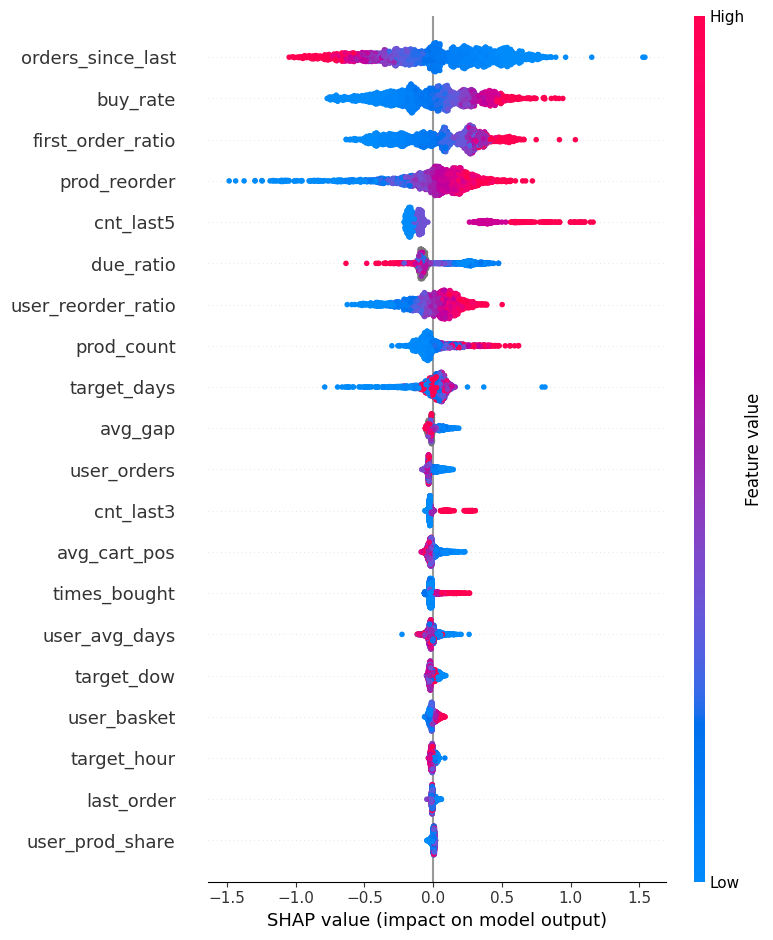

In [14]:
if "cnt_last5" in d2.columns:
    d2 = d2.drop(columns=["cnt_last5"])

r5 = (
    up2[up2.order_number > up2.user_orders - 5]
    .groupby(["user_id", "product_id"])
    .size()
    .rename("cnt_last5")
    .reset_index()
)
d2 = d2.merge(r5, on=["user_id", "product_id"], how="left")
d2["cnt_last5"] = d2.cnt_last5.fillna(0)

d2["orders_since_first"] = d2.user_orders - d2.first_order + 1
d2["first_order_ratio"] = d2.times_bought / d2.orders_since_first

total_user_items = d2.user_orders * d2.user_basket
d2["user_prod_share"] = d2.times_bought / (total_user_items + 1e-5)

feats_extended = feats_full + [
    "cnt_last5",
    "first_order_ratio",
    "user_prod_share",
]

run_cv_full(feats_extended, "extended version")

X_final = d2[feats_extended]
final_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.8,
    subsample_freq=1, colsample_bytree=0.8, scale_pos_weight=3.5, random_state=42, verbose=-1,
)
final_model.fit(X_final, y2)

sample = X_final.sample(2000, random_state=42)
sv = shap.TreeExplainer(final_model).shap_values(sample)
sv1 = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if sv.ndim == 3 else sv)
shap.summary_plot(sv1, sample)